<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%202/01_probability_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Probability Basics
**Week 2 | Mathematical Foundations for RL**

By the end of this notebook you will:
- Simulate discrete and continuous random variables
- Compute empirical mean, variance, and compare to theoretical values
- Visualise distributions and understand their shape

These are the building blocks for understanding stochastic rewards in RL.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Dice Simulation
A fair 6-sided die — simplest discrete random variable.

Empirical mean:     3.4999  (theoretical: 3.5000)
Empirical variance: 2.9194  (theoretical: 2.9167)


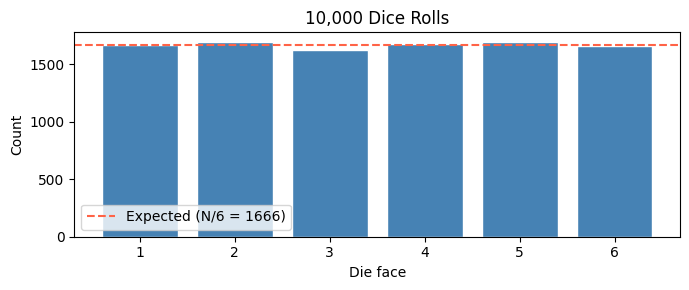

In [2]:
# Simulate N dice rolls
N = 10_000
rolls = np.random.randint(1, 7, size=N)

# Theoretical values
theoretical_mean = 3.5
theoretical_var  = 35/12  # (b-a+1)^2 - 1) / 12 for uniform discrete

print(f"Empirical mean:     {rolls.mean():.4f}  (theoretical: {theoretical_mean:.4f})")
print(f"Empirical variance: {rolls.var():.4f}  (theoretical: {theoretical_var:.4f})")

plt.figure(figsize=(7, 3))
counts, _, bars = plt.hist(rolls, bins=np.arange(0.5, 7.5, 1), edgecolor='white', color='steelblue', rwidth=0.8)
plt.axhline(N/6, color='tomato', linestyle='--', label=f'Expected (N/6 = {N//6})')
plt.xlabel('Die face'); plt.ylabel('Count'); plt.title('10,000 Dice Rolls')
plt.xticks(range(1,7)); plt.legend(); plt.tight_layout(); plt.show()

## 2. Continuous Distribution — Normal
Many RL reward signals are approximately Gaussian.

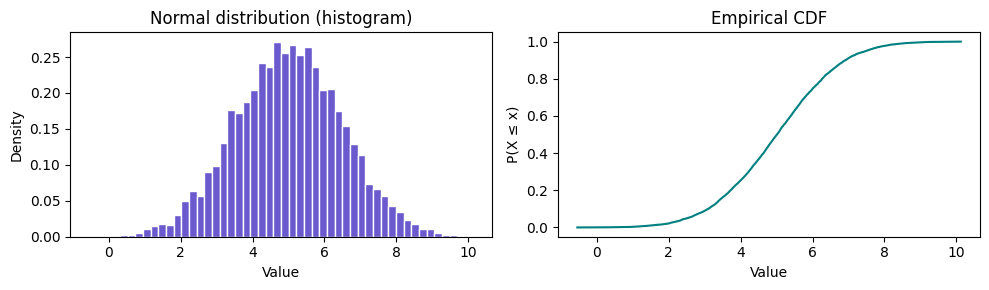

Mean: 5.002 (true: 5.0)
Std:  1.500  (true: 1.5)


In [3]:
mu, sigma = 5.0, 1.5
samples = np.random.normal(mu, sigma, size=N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(samples, bins=50, color='slateblue', edgecolor='white', density=True)
axes[0].set_title('Normal distribution (histogram)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')

# Empirical CDF
sorted_s = np.sort(samples)
cdf = np.arange(1, N+1) / N
axes[1].plot(sorted_s, cdf, color='teal', linewidth=1.5)
axes[1].set_title('Empirical CDF')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('P(X ≤ x)')
plt.tight_layout(); plt.show()

print(f"Mean: {samples.mean():.3f} (true: {mu})")
print(f"Std:  {samples.std():.3f}  (true: {sigma})")

## 3. Expectation and Variance — Intuition
Expectation = centre of mass of the distribution.  
Variance = average squared distance from the mean (spread).

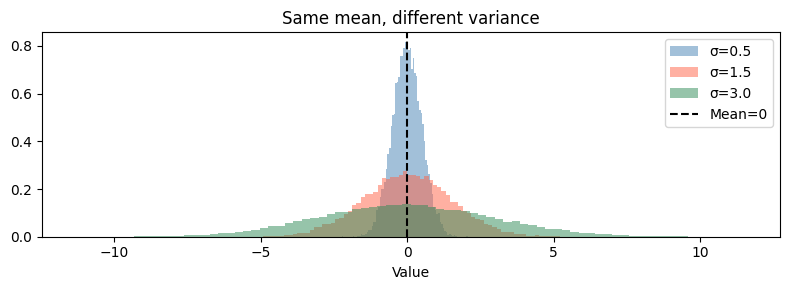

In [4]:
# Compare two distributions with same mean but different variance
fig, ax = plt.subplots(figsize=(8, 3))
for sigma_, color_, label_ in [(0.5,'steelblue','σ=0.5'), (1.5,'tomato','σ=1.5'), (3.0,'seagreen','σ=3.0')]:
    s = np.random.normal(0, sigma_, 20_000)
    ax.hist(s, bins=80, alpha=0.5, density=True, color=color_, label=label_)
ax.axvline(0, color='black', linestyle='--', label='Mean=0')
ax.set_title('Same mean, different variance'); ax.legend(); ax.set_xlabel('Value')
plt.tight_layout(); plt.show()

## 4. The Law of Large Numbers
As we collect more samples, the empirical mean converges to E[X].  
This is why RL agents improve with experience.

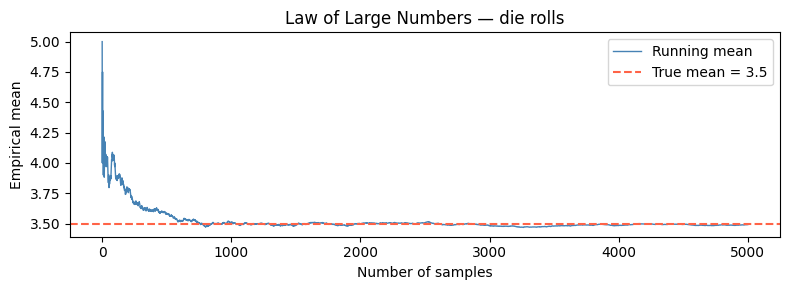

In [5]:
true_mean = 3.5
rolls_seq = np.random.randint(1, 7, size=5000)
running_mean = np.cumsum(rolls_seq) / np.arange(1, 5001)

plt.figure(figsize=(8, 3))
plt.plot(running_mean, color='steelblue', linewidth=1, label='Running mean')
plt.axhline(true_mean, color='tomato', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Number of samples'); plt.ylabel('Empirical mean')
plt.title('Law of Large Numbers — die rolls')
plt.legend(); plt.tight_layout(); plt.show()

## ✅ Exercise
1. Change `mu` and `sigma` in section 2. What happens to the histogram shape?
2. In section 4, replace dice rolls with samples from an exponential distribution (`np.random.exponential`). Does LLN still hold?
3. **Challenge**: simulate 1000 coin flips (0/1). Plot the running fraction of heads. What does it converge to?

**Exercise 1:**
* **Changing `mu` (Mean):** Shifts the peak of the bell curve left or right along the x-axis.
* **Changing `sigma` (Standard Deviation):** Alters the spread. A higher `sigma` makes the curve shorter and wider, while a lower `sigma` makes it taller and narrower.

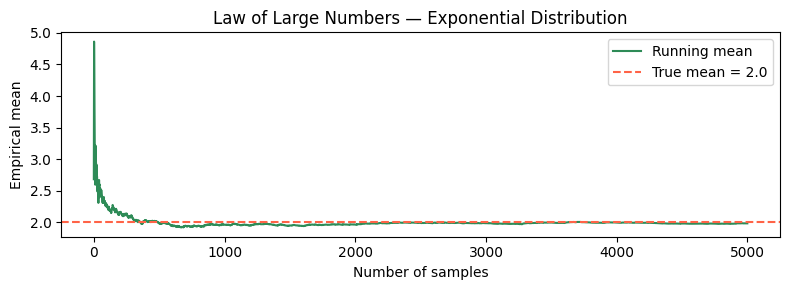

In [6]:
# Exercise 2: Law of Large Numbers with Exponential Distribution
true_mean_exp = 2.0
exp_samples = np.random.exponential(scale=true_mean_exp, size=5000)

running_mean_exp = np.cumsum(exp_samples) / np.arange(1, 5001)

plt.figure(figsize=(8, 3))
plt.plot(running_mean_exp, color='seagreen', linewidth=1.5, label='Running mean')
plt.axhline(true_mean_exp, color='tomato', linestyle='--', label=f'True mean = {true_mean_exp}')
plt.xlabel('Number of samples')
plt.ylabel('Empirical mean')
plt.title('Law of Large Numbers — Exponential Distribution')
plt.legend()
plt.tight_layout()
plt.show()

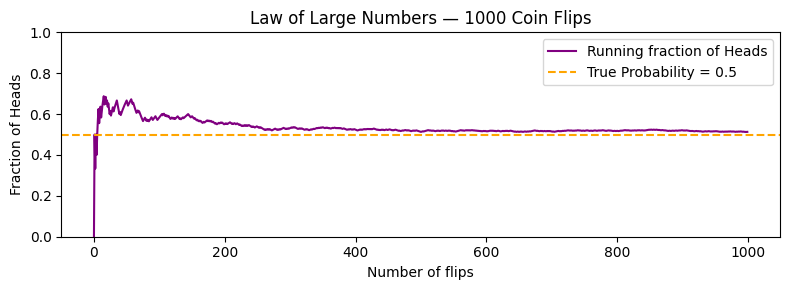

In [8]:
# Exercise 3: 1000 Coin Flips Challenge
# 0 = Tails, 1 = Heads
flips = np.random.randint(0, 2, size=1000)

# Calculate running fraction of heads
running_fraction_heads = np.cumsum(flips) / np.arange(1, 1001)

plt.figure(figsize=(8, 3))
plt.plot(running_fraction_heads, color='purple', linewidth=1.5, label='Running fraction of Heads')
plt.axhline(0.5, color='orange', linestyle='--', label='True Probability = 0.5')
plt.xlabel('Number of flips')
plt.ylabel('Fraction of Heads')
plt.title('Law of Large Numbers — 1000 Coin Flips')
plt.ylim(0, 1) # Keeps the y-axis between 0 and 1
plt.legend()
plt.tight_layout()
plt.show()